In [1]:
import scipy

In [2]:
mat_path = 'BG_031_010525.mat'
data = scipy.io.loadmat(mat_path, struct_as_record=False, squeeze_me=True)

In [3]:
import numpy as np

def mat_struct_to_dict(obj):
    if isinstance(obj, np.ndarray):
        # If it's an array of objects, recursively convert each element
        if obj.dtype == 'O':
            return [mat_struct_to_dict(o) for o in obj]
        else:
            return obj
    elif hasattr(obj, '_fieldnames'):
        return {field: mat_struct_to_dict(getattr(obj, field)) for field in obj._fieldnames}
    else:
        return obj

# Use this function instead of todict
data_dict1 = mat_struct_to_dict(data)

In [5]:
data_dict1.keys()

dict_keys(['__header__', '__version__', '__globals__', 'ans'])

In [6]:
try:
    data_dict = mat_struct_to_dict(data_dict1['data'])
except KeyError:
    data_dict = mat_struct_to_dict(data_dict1['ans'])

In [7]:
# Inspect the structure of data_dict after conversion
print(type(data_dict))

if isinstance(data_dict, (list, np.ndarray)):
    print(f"Length: {len(data_dict)}")
    print(f"Type of first element: {type(data_dict[0])}")
    if isinstance(data_dict[0], dict):
        print(data_dict[0].keys())
    inner = data_dict[0]
elif isinstance(data_dict, dict):
    print(data_dict.keys())
    # Get the first value from the dictionary
    first_key = next(iter(data_dict))
    inner = data_dict[first_key]
    print(f"Accessed inner using key: {first_key}")
else:
    inner = data_dict
    print("data_dict is neither a list nor a dict.")

print(type(inner))

# If still an array, keep unwrapping
if isinstance(inner, (list, np.ndarray)):
    print(f"Length: {len(inner)}")
    print(f"Type of first element: {type(inner[0])}")
    if isinstance(inner[0], dict):
        print(inner[0].keys())
    struct = inner[0]
elif isinstance(inner, dict):
    print(inner.keys())
    # Get the first value from the dictionary
    first_key = next(iter(inner))
    struct = inner[first_key]
    print(f"Accessed struct using key: {first_key}")
else:
    struct = inner
    print("inner is neither a list nor a dict.")

# Drill down further if struct is still a dict
while isinstance(struct, dict):
    print("Current struct is a dict. Keys:", struct.keys())
    first_key = next(iter(struct))
    struct = struct[first_key]
    print(f"Drilled down using key: {first_key}")

# List available field names if it's a numpy structured array
if hasattr(struct, 'dtype') and struct.dtype.names:
    print(struct.dtype.names)
    # Print the type of each field for inspection
    for name in struct.dtype.names:
        print(f"{name}: type={type(struct[name])}")
else:
    print("No dtype.names found or struct is not a numpy structured array. Final type:", type(struct))

<class 'dict'>
dict_keys(['BG_031'])
Accessed inner using key: BG_031
<class 'dict'>
dict_keys(['BG_031_01052025'])
Accessed struct using key: BG_031_01052025
Current struct is a dict. Keys: dict_keys(['NPX_probes', 'NI_events', 'behav_data'])
Drilled down using key: NPX_probes
Current struct is a dict. Keys: dict_keys(['dat_path', 'n_channels_dat', 'dtype', 'offset', 'sample_rate', 'hp_filtered', 'st', 'clu', 'cgs', 'cids', 'xcoords', 'ycoords', 'pcFeat', 'pcFeatInd', 'cluster_id_KS_good', 'templateDepths', 'templateWaveforms'])
Drilled down using key: dat_path
No dtype.names found or struct is not a numpy structured array. Final type: <class 'str'>


In [8]:
data_dict['BG_031'].keys()

dict_keys(['BG_031_01052025'])

In [9]:
drilled_down =data_dict['BG_031']['BG_031_01052025']

In [10]:
drilled_down.keys()

dict_keys(['NPX_probes', 'NI_events', 'behav_data'])

# PSTH and Raster for Trials with a Specific Outcome
This cell demonstrates how to plot PSTHs and rasters for only those trials with a selected outcome (e.g., 'Hit'), using the event_times_outcome variable from the previous cell.

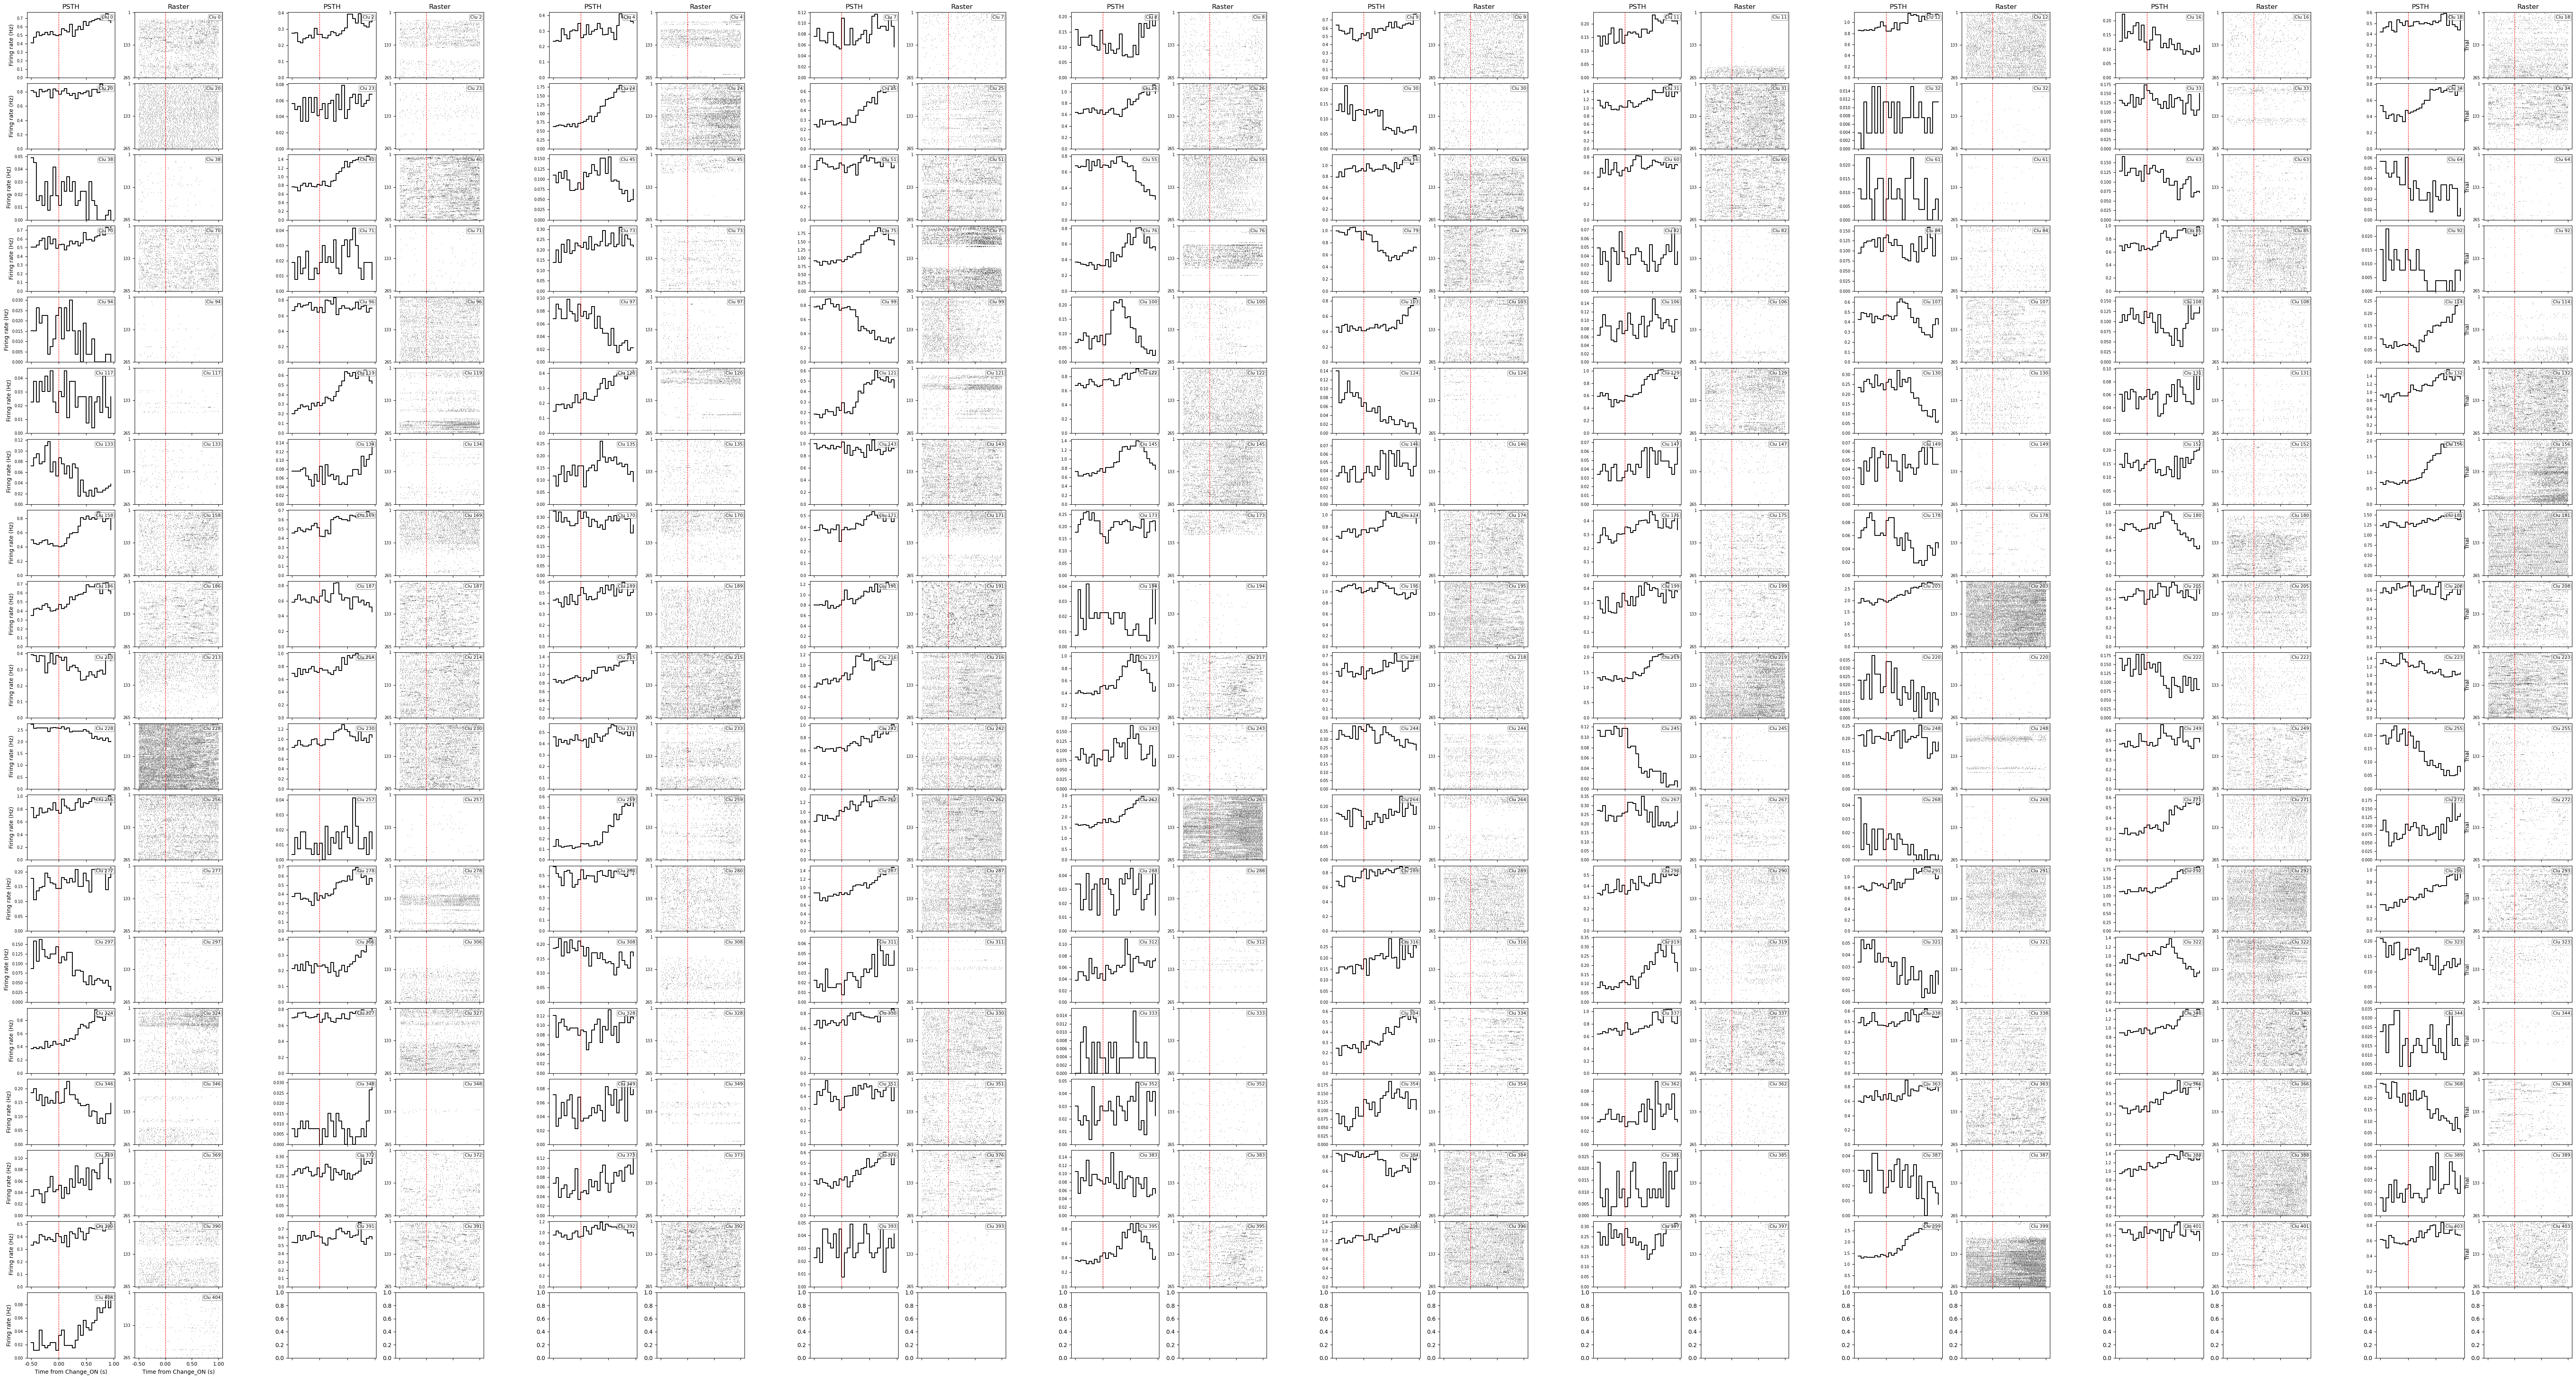

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- USER OPTIONS ---
align_to = 'Change_ON'  # e.g., 'Change_ON', 'Baseline_ON', 'trialoutcome_time', etc.
outcome_of_interest = 'Hit'  # e.g., 'Hit', or None for all outcomes
clusters_per_row = 10  # Number of cluster pairs (PSTH/raster) per row

# --- DATA ACCESS ---
session = drilled_down
npx_probes = session['NPX_probes']
ni_events = session['NI_events']
behav_data = session['behav_data']
spike_times = npx_probes['st']
cluster_ids = npx_probes['clu']

# --- TRIAL OUTCOME LOGIC ---
trials = behav_data['trials_data_exp']
outcomes = np.array([trial['trialoutcome'] for trial in trials])
n_trials = len(trials)

# --- EVENT TIME SELECTION ---
if align_to in ni_events:
    event_arr = ni_events[align_to]
    if isinstance(event_arr, dict) and 'rise_t' in event_arr:
        event_times_all = np.array(event_arr['rise_t']).flatten()
    else:
        event_times_all = np.array(event_arr).flatten()
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
    align_label = align_to
elif align_to == 'trialoutcome_time':
    event_times_all = np.array([trial['hit_time'] for trial in trials])
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
    align_label = 'Hit Time'
else:
    raise ValueError(f"Unknown align_to: {align_to}")

# --- CLUSTER SELECTION & FILTERING ---
good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
clusters_to_plot = []
rasters_for_plot = []
counts_for_plot = []
for clu in good_clusters:
    spike_times_clu = spike_times[cluster_ids == clu]
    all_counts = []
    all_rasters = []
    for t in event_times:
        aligned = spike_times_clu - t
        counts, _ = np.histogram(aligned, bins=np.arange(-0.5, 1.0+0.05, 0.05))
        all_counts.append(counts)
        mask = (aligned >= -0.5) & (aligned <= 1.0)
        all_rasters.append(aligned[mask])
    n_trials_with_spikes = sum(len(ras) > 0 for ras in all_rasters)
    if n_trials_with_spikes > 20:
        clusters_to_plot.append(clu)
        rasters_for_plot.append(all_rasters)
        counts_for_plot.append(all_counts)

n_plot = len(clusters_to_plot)
window = [-0.5, 1.0]
bin_size = 0.05
bins = np.arange(window[0], window[1] + bin_size, bin_size)

# --- GRID SETUP ---
n_cols = clusters_per_row * 2 + (clusters_per_row - 1)  # Add a spacer column between each pair
n_rows = int(np.ceil(n_plot / clusters_per_row))
# Set width ratios: [1,1,0.3,1,1,0.3,...,1,1]
width_ratios = []
for i in range(clusters_per_row):
    width_ratios.extend([1, 1])
    if i < clusters_per_row - 1:
        width_ratios.append(0.3)  # Spacer between pairs
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 1.8 * n_rows), sharex='col', gridspec_kw={'width_ratios': width_ratios})
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

# --- PLOTTING ---
for idx, (clu, all_rasters, all_counts) in enumerate(zip(clusters_to_plot, rasters_for_plot, counts_for_plot)):
    row = idx // clusters_per_row
    col_pair = idx % clusters_per_row
    base_col = col_pair * 3  # Each pair: PSTH, Raster, Spacer
    ax_psth = axes[row, base_col]
    ax_raster = axes[row, base_col + 1]
    psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
    # PSTH
    ax_psth.step(bins[:-1], psth, where='post', color='k')
    ax_psth.axvline(0, color='r', linestyle='--', lw=0.8)
    ax_psth.set_ylim(bottom=0)
    ax_psth.tick_params(axis='y', labelsize=7)
    ax_psth.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_psth.transAxes,
                 bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
    if row == n_rows - 1:
        xticks = [window[0], -0.5, 0, 0.5, window[1]]
        xticks = sorted(set([x for x in xticks if window[0] <= x <= window[1]]))
        ax_psth.set_xticks(xticks)
        ax_psth.set_xticklabels([f"{b:.2f}" for b in xticks], rotation=0, fontsize=9)
        ax_psth.set_xlabel(f'Time from {align_label} (s)')
    else:
        ax_psth.set_xticklabels([])
    if col_pair == 0:
        ax_psth.set_ylabel('Firing rate (Hz)')
    # Raster
    n_trials_raster = len(all_rasters)
    for trial, ras in enumerate(all_rasters):
        ax_raster.vlines(ras, trial + 0.5, trial + 1.5, color='k', lw=0.5)
    ax_raster.axvline(0, color='r', linestyle='--', lw=0.8)
    ax_raster.set_ylim(0.5, n_trials_raster + 0.5)
    # Set yticks for this cluster's raster
    if n_trials_raster >= 3:
        trial_ticks = [1, n_trials_raster // 2 + 1, n_trials_raster]
    else:
        trial_ticks = list(range(1, n_trials_raster + 1))
    ax_raster.set_yticks(trial_ticks)
    ax_raster.set_yticklabels([str(t) for t in trial_ticks], fontsize=7)
    ax_raster.invert_yaxis()  # So trial 1 is at the top
    ax_raster.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_raster.transAxes,
                  bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
    if row == n_rows - 1:
        ax_raster.set_xticks(xticks)
        ax_raster.set_xticklabels([f"{b:.2f}" for b in xticks], rotation=0, fontsize=9)
        ax_raster.set_xlabel(f'Time from {align_label} (s)')
    else:
        ax_raster.set_xticklabels([])
    if col_pair == clusters_per_row - 1:
        ax_raster.set_ylabel('Trial')
    if row == 0:
        ax_psth.set_title('PSTH')
        ax_raster.set_title('Raster')

# Hide spacer columns
for row in range(n_rows):
    for i in range(clusters_per_row - 1):
        spacer_col = i * 3 + 2
        axes[row, spacer_col].axis('off')

plt.tight_layout(h_pad=0.2, w_pad=0.05)
plt.show()

# Compare Mean PSTH for Different Outcomes (Same Clusters Option)
This cell compares the mean PSTH for different behavioral outcomes (e.g., 'Hit' vs 'Miss') aligned to a chosen event, with the option to use only clusters that pass the spike-in-trials filter for all outcomes.

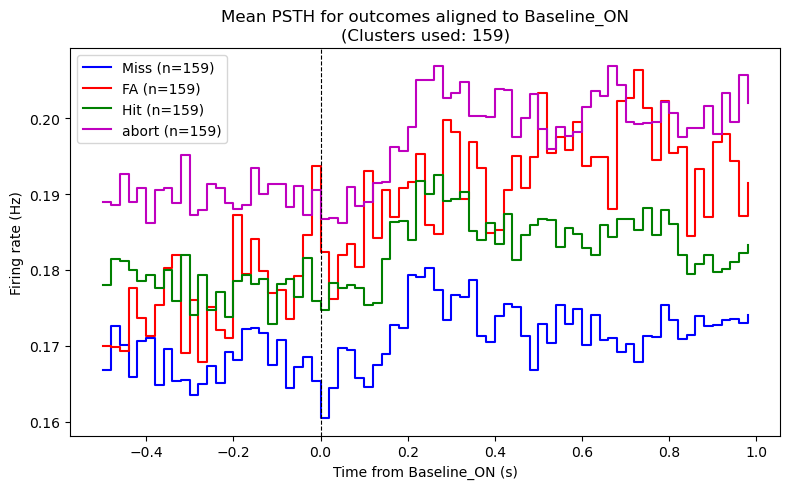

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- USER OPTIONS ---
align_to = 'Baseline_ON'  # e.g., 'Change_ON', 'Baseline_ON', 'trialoutcome_time', etc.
outcomes_to_compare = ['Miss','FA','Hit','abort']  # List of outcomes to compare
min_trials_with_spikes = 20  # Only include clusters with > this many trials with spikes
use_same_clusters = True  # If True, only clusters passing filter for ALL outcomes are used

# --- DATA ACCESS ---
session = drilled_down
npx_probes = session['NPX_probes']
ni_events = session['NI_events']
behav_data = session['behav_data']
spike_times = npx_probes['st']
cluster_ids = npx_probes['clu']

# --- TRIAL OUTCOME LOGIC ---
trials = behav_data['trials_data_exp']
outcomes = np.array([trial['trialoutcome'] for trial in trials])
n_trials = len(trials)

# --- PSTH Parameters ---
window = [-0.5, 1.0]
bin_size = 0.02
bins = np.arange(window[0], window[1] + bin_size, bin_size)

# --- Collect PSTHs for all clusters and outcomes ---
good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
all_psths_by_outcome = {outcome: {} for outcome in outcomes_to_compare}
clusters_passing = {outcome: set() for outcome in outcomes_to_compare}

for outcome_of_interest in outcomes_to_compare:
    # --- EVENT TIME SELECTION ---
    if align_to in ni_events:
        event_arr = ni_events[align_to]
        if isinstance(event_arr, dict) and 'rise_t' in event_arr:
            event_times_all = np.array(event_arr['rise_t']).flatten()
        else:
            event_times_all = np.array(event_arr).flatten()
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        align_label = align_to
    elif align_to == 'trialoutcome_time':
        event_times_all = np.array([trial['hit_time'] for trial in trials])
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        align_label = 'Hit Time'
    else:
        raise ValueError(f"Unknown align_to: {align_to}")
    for clu in good_clusters:
        spike_times_clu = spike_times[cluster_ids == clu]
        all_counts = []
        all_rasters = []
        for t in event_times:
            aligned = spike_times_clu - t
            counts, _ = np.histogram(aligned, bins=bins)
            all_counts.append(counts)
            mask_spk = (aligned >= window[0]) & (aligned <= window[1])
            all_rasters.append(aligned[mask_spk])
        n_trials_with_spikes = sum(len(ras) > 0 for ras in all_rasters)
        if n_trials_with_spikes > min_trials_with_spikes:
            psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
            all_psths_by_outcome[outcome_of_interest][clu] = psth
            clusters_passing[outcome_of_interest].add(clu)

# --- Determine clusters to use ---
if use_same_clusters:
    # Only clusters that pass for all outcomes
    clusters_to_use = set.intersection(*[clusters_passing[o] for o in outcomes_to_compare])
else:
    # Use all clusters that pass for each outcome (may differ)
    clusters_to_use = set.union(*[clusters_passing[o] for o in outcomes_to_compare])

# --- Compute mean PSTH for each outcome using selected clusters ---
mean_psths = {}
counts_per_outcome = {}
for outcome in outcomes_to_compare:
    psths = [all_psths_by_outcome[outcome][clu] for clu in clusters_to_use if clu in all_psths_by_outcome[outcome]]
    psths = np.array(psths)
    mean_psths[outcome] = np.mean(psths, axis=0) if len(psths) > 0 else np.zeros(len(bins)-1)
    counts_per_outcome[outcome] = len(psths)

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
colors = ['b', 'r', 'g', 'm', 'c']
for i, outcome in enumerate(outcomes_to_compare):
    plt.step(bins[:-1], mean_psths[outcome], where='post', label=f"{outcome} (n={counts_per_outcome[outcome]})", color=colors[i % len(colors)])
plt.axvline(0, color='k', linestyle='--', lw=0.8)
plt.xlabel(f'Time from {align_label} (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'Mean PSTH for outcomes aligned to {align_label}\n(Clusters used: {len(clusters_to_use)})')
plt.legend()
plt.tight_layout()
plt.show()

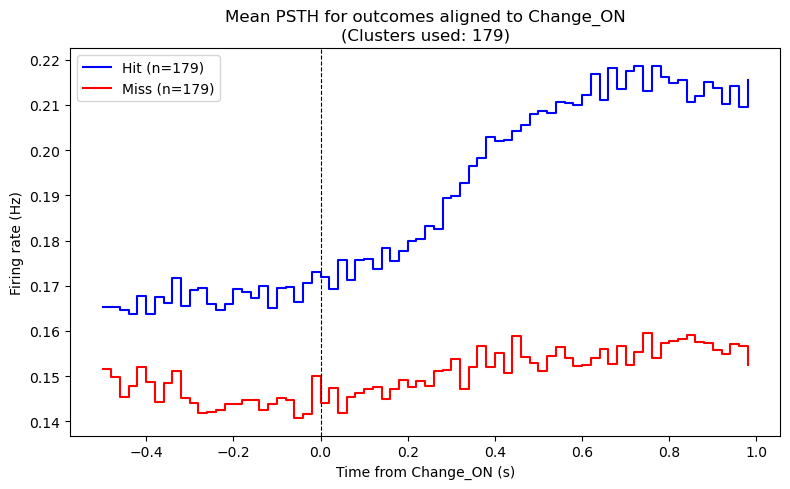

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- USER OPTIONS ---
align_to = 'Change_ON'  # e.g., 'Change_ON', 'Baseline_ON', 'trialoutcome_time', etc.
outcomes_to_compare = ['Hit', 'Miss']  # List of outcomes to compare
min_trials_with_spikes = 20  # Only include clusters with > this many trials with spikes
use_same_clusters = True  # If True, only clusters passing filter for ALL outcomes are used

# --- DATA ACCESS ---
session = drilled_down
npx_probes = session['NPX_probes']
ni_events = session['NI_events']
behav_data = session['behav_data']
spike_times = npx_probes['st']
cluster_ids = npx_probes['clu']

# --- TRIAL OUTCOME LOGIC ---
trials = behav_data['trials_data_exp']
outcomes = np.array([trial['trialoutcome'] for trial in trials])
n_trials = len(trials)

# --- PSTH Parameters ---
window = [-0.5, 1.0]
bin_size = 0.02
bins = np.arange(window[0], window[1] + bin_size, bin_size)

# --- Collect PSTHs for all clusters and outcomes ---
good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
all_psths_by_outcome = {outcome: {} for outcome in outcomes_to_compare}
clusters_passing = {outcome: set() for outcome in outcomes_to_compare}

for outcome_of_interest in outcomes_to_compare:
    # --- EVENT TIME SELECTION ---
    if align_to in ni_events:
        event_arr = ni_events[align_to]
        if isinstance(event_arr, dict) and 'rise_t' in event_arr:
            event_times_all = np.array(event_arr['rise_t']).flatten()
        else:
            event_times_all = np.array(event_arr).flatten()
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        align_label = align_to
    elif align_to == 'trialoutcome_time':
        event_times_all = np.array([trial['hit_time'] for trial in trials])
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        align_label = 'Hit Time'
    else:
        raise ValueError(f"Unknown align_to: {align_to}")
    for clu in good_clusters:
        spike_times_clu = spike_times[cluster_ids == clu]
        all_counts = []
        all_rasters = []
        for t in event_times:
            aligned = spike_times_clu - t
            counts, _ = np.histogram(aligned, bins=bins)
            all_counts.append(counts)
            mask_spk = (aligned >= window[0]) & (aligned <= window[1])
            all_rasters.append(aligned[mask_spk])
        n_trials_with_spikes = sum(len(ras) > 0 for ras in all_rasters)
        if n_trials_with_spikes > min_trials_with_spikes:
            psth = np.mean(all_counts, axis=0) if len(all_counts) > 0 else np.zeros(len(bins)-1)
            all_psths_by_outcome[outcome_of_interest][clu] = psth
            clusters_passing[outcome_of_interest].add(clu)

# --- Determine clusters to use ---
if use_same_clusters:
    # Only clusters that pass for all outcomes
    clusters_to_use = set.intersection(*[clusters_passing[o] for o in outcomes_to_compare])
else:
    # Use all clusters that pass for each outcome (may differ)
    clusters_to_use = set.union(*[clusters_passing[o] for o in outcomes_to_compare])

# --- Compute mean PSTH for each outcome using selected clusters ---
mean_psths = {}
counts_per_outcome = {}
for outcome in outcomes_to_compare:
    psths = [all_psths_by_outcome[outcome][clu] for clu in clusters_to_use if clu in all_psths_by_outcome[outcome]]
    psths = np.array(psths)
    mean_psths[outcome] = np.mean(psths, axis=0) if len(psths) > 0 else np.zeros(len(bins)-1)
    counts_per_outcome[outcome] = len(psths)

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
colors = ['b', 'r', 'g', 'm', 'c']
for i, outcome in enumerate(outcomes_to_compare):
    plt.step(bins[:-1], mean_psths[outcome], where='post', label=f"{outcome} (n={counts_per_outcome[outcome]})", color=colors[i % len(colors)])
plt.axvline(0, color='k', linestyle='--', lw=0.8)
plt.xlabel(f'Time from {align_label} (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'Mean PSTH for outcomes aligned to {align_label}\n(Clusters used: {len(clusters_to_use)})')
plt.legend()
plt.tight_layout()
plt.show()

# Grid PSTH/Raster Plot: Sorted by Mean Firing Rate (Hz), Outcome-Colored Rasters
This cell sorts clusters by mean firing rate (Hz) in the window and, if plotting all outcomes, colors each trial's raster by its outcome. The PSTH y-axis is now in Hz (spikes/sec).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# --- USER OPTIONS ---
align_to = 'Baseline_ON'  # e.g., 'Change_ON', 'Baseline_ON', 'trialoutcome_time', etc.
outcome_of_interest = 'Hit'  # None = all outcomes
clusters_per_row = 10
min_trials_with_spikes = 20
use_numba = False
save_figure = True  # Set to True to save the figure instead of showing it interactively

# --- DATA ACCESS ---
session = drilled_down
npx_probes = session['NPX_probes']
ni_events = session['NI_events']
behav_data = session['behav_data']
spike_times = npx_probes['st']
cluster_ids = npx_probes['clu']

# --- TRIAL OUTCOME LOGIC ---
trials = behav_data['trials_data_exp']
outcomes = np.array([trial['trialoutcome'] for trial in trials])
n_trials = len(trials)

# --- EVENT TIME SELECTION ---
if align_to in ni_events:
    event_arr = ni_events[align_to]
    if isinstance(event_arr, dict) and 'rise_t' in event_arr:
        event_times_all = np.array(event_arr['rise_t']).flatten()
    else:
        event_times_all = np.array(event_arr).flatten()
    if len(event_times_all) == 0:
        raise ValueError(f"Event array for {align_to} is empty. Check your data.")
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
        trial_outcomes = outcomes[mask]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
        trial_outcomes = outcomes
    align_label = align_to
elif align_to == 'trialoutcome_time':
    event_times_all = np.array([trial['hit_time'] for trial in trials])
    if len(event_times_all) == 0:
        raise ValueError("Event array for trialoutcome_time is empty. Check your data.")
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
        trial_outcomes = outcomes[mask]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
        trial_outcomes = outcomes
    align_label = 'Hit Time'
else:
    raise ValueError(f"Unknown align_to: {align_to}")

# --- CLUSTER SELECTION & FILTERING (FAST, CORRECT) ---
good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
window = [-0.5, 1.0]
bin_size = 0.05
bins = np.arange(window[0], window[1] + bin_size, bin_size)
window_length = window[1] - window[0]  # total window in seconds
clusters_to_plot = []
rasters_for_plot = []
counts_for_plot = []
mean_rates = []

# Optional: numba-accelerated histogramming
try:
    from numba import njit
    numba_available = True
except ImportError:
    numba_available = False
    use_numba = False

def trial_histogram(spikes, event_times, bins, window):
    # For each trial, align spikes and histogram
    all_counts = []
    all_rasters = []
    for t in event_times:
        aligned = spikes - t
        mask = (aligned >= window[0]) & (aligned <= window[1])
        all_rasters.append(aligned[mask])
        all_counts.append(np.histogram(aligned[mask], bins=bins)[0])
    return all_counts, all_rasters

def trial_histogram_numba(spikes, event_times, bins, window):
    n_trials = len(event_times)
    n_bins = len(bins) - 1
    all_counts = np.zeros((n_trials, n_bins), dtype=np.int32)
    for i in range(n_trials):
        t = event_times[i]
        aligned = spikes - t
        mask = (aligned >= window[0]) & (aligned <= window[1])
        h, _ = np.histogram(aligned[mask], bins=bins)
        all_counts[i, :] = h
    return all_counts

if use_numba and numba_available:
    trial_histogram_numba = njit(trial_histogram_numba)

for clu in good_clusters:
    spike_times_clu = spike_times[cluster_ids == clu]
    if use_numba and numba_available:
        all_counts = trial_histogram_numba(spike_times_clu, event_times, bins, window)
        all_rasters = []
        for t in event_times:
            aligned = spike_times_clu - t
            mask = (aligned >= window[0]) & (aligned <= window[1])
            all_rasters.append(aligned[mask])
    else:
        all_counts, all_rasters = trial_histogram(spike_times_clu, event_times, bins, window)
        all_counts = np.array(all_counts)
    n_trials_with_spikes = sum(len(ras) > 0 for ras in all_rasters)
    if n_trials_with_spikes > min_trials_with_spikes:
        clusters_to_plot.append(clu)
        rasters_for_plot.append(all_rasters)
        counts_for_plot.append(all_counts)
        # mean firing rate (Hz) for sorting: total spikes / (n_trials * window length in seconds)
        mean_rate = np.sum(all_counts) / (len(all_counts) * window_length)
        mean_rates.append(mean_rate)

# --- SORT CLUSTERS BY MEAN FIRING RATE (Hz) ---
if len(mean_rates) == 0:
    print("No clusters passed the spike-in-trials filter. Adjust your parameters.")
else:
    sort_idx = np.argsort(mean_rates)[::-1]  # Descending order
    clusters_to_plot = [clusters_to_plot[i] for i in sort_idx]
    rasters_for_plot = [rasters_for_plot[i] for i in sort_idx]
    counts_for_plot = [counts_for_plot[i] for i in sort_idx]
    mean_rates = [mean_rates[i] for i in sort_idx]

    # --- OUTCOME COLORS ---
    unique_outcomes = np.unique(trial_outcomes)
    color_map = cm.get_cmap('tab10', len(unique_outcomes))
    outcome_to_color = {o: color_map(i) for i, o in enumerate(unique_outcomes)}

    # --- GRID SETUP ---
    n_plot = len(clusters_to_plot)
    n_cols = clusters_per_row * 2 + (clusters_per_row - 1)
    n_rows = int(np.ceil(n_plot / clusters_per_row))
    width_ratios = []
    for i in range(clusters_per_row):
        width_ratios.extend([1, 1])
        if i < clusters_per_row - 1:
            width_ratios.append(0.3)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 1.8 * n_rows), sharex='col', gridspec_kw={'width_ratios': width_ratios})
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    def set_xticks_labels(ax, window, align_label):
        xticks = [window[0], -0.5, 0, 0.5, window[1]]
        xticks = sorted(set([x for x in xticks if window[0] <= x <= window[1]]))
        ax.set_xticks(xticks)
        ax.set_xticklabels([f"{b:.2f}" for b in xticks], rotation=0, fontsize=9)
        ax.set_xlabel(f'Time from {align_label} (s)')

    # --- PLOTTING ---
    for idx, (clu, all_rasters, all_counts) in enumerate(zip(clusters_to_plot, rasters_for_plot, counts_for_plot)):
        row = idx // clusters_per_row
        col_pair = idx % clusters_per_row
        base_col = col_pair * 3
        ax_psth = axes[row, base_col]
        ax_raster = axes[row, base_col + 1]
        # PSTH: mean spike count per bin per trial, divided by bin size (Hz)
        psth = np.mean(all_counts, axis=0) / bin_size if len(all_counts) > 0 else np.zeros(len(bins)-1)
        ax_psth.step(bins[:-1], psth, where='post', color='k')
        ax_psth.axvline(0, color='r', linestyle='--', lw=0.8)
        ax_psth.set_ylim(bottom=0)
        ax_psth.tick_params(axis='y', labelsize=7)
        ax_psth.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_psth.transAxes,
                     bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
        if row == n_rows - 1:
            set_xticks_labels(ax_psth, window, align_label)
        else:
            ax_psth.set_xticklabels([])
        if col_pair == 0:
            ax_psth.set_ylabel('Firing rate (Hz)')
        # Raster
        n_trials_raster = len(all_rasters)
        for trial, ras in enumerate(all_rasters):
            if outcome_of_interest is None:
                color = outcome_to_color.get(trial_outcomes[trial], 'k')
            else:
                color = 'k'
            ax_raster.vlines(ras, trial + 0.5, trial + 1.5, color=color, lw=0.5)
        ax_raster.axvline(0, color='r', linestyle='--', lw=0.8)
        ax_raster.set_ylim(0.5, n_trials_raster + 0.5)
        if n_trials_raster >= 3:
            trial_ticks = [1, n_trials_raster // 2 + 1, n_trials_raster]
        else:
            trial_ticks = list(range(1, n_trials_raster + 1))
        ax_raster.set_yticks(trial_ticks)
        ax_raster.set_yticklabels([str(t) for t in trial_ticks], fontsize=7)
        ax_raster.invert_yaxis()
        ax_raster.text(0.98, 0.95, f'Clu {clu}', ha='right', va='top', fontsize=8, transform=ax_raster.transAxes,
                      bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.2', alpha=0.7))
        if row == n_rows - 1:
            set_xticks_labels(ax_raster, window, align_label)
        else:
            ax_raster.set_xticklabels([])
        if col_pair == clusters_per_row - 1:
            ax_raster.set_ylabel('Trial')
        if row == 0:
            ax_psth.set_title('PSTH')
            ax_raster.set_title('Raster')

    # Hide spacer columns
    for row in range(n_rows):
        for i in range(clusters_per_row - 1):
            spacer_col = i * 3 + 2
            axes[row, spacer_col].axis('off')

    # Add legend for outcome colors if plotting all outcomes
    if outcome_of_interest is None:
        handles = [plt.Line2D([0], [0], color=outcome_to_color[o], lw=2, label=str(o)) for o in unique_outcomes]
        fig.legend(handles=handles, loc='upper right', title='Outcome', fontsize=8)

    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    import os
    output_dir = 'png_output'
    os.makedirs(output_dir, exist_ok=True)
    if save_figure:
        fig.savefig(os.path.join(output_dir, f'clusters_grid_sorted_Hz.png'), dpi=150)
        plt.close(fig)
    else:
        plt.show()

C:\Users\Ben\AppData\Local\Temp\ipykernel_15940\3662609880.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('tab10', len(unique_outcomes))


# Heatmap visualization of firing rates per trial per cluster

In [15]:
#This cell visualizes the per-trial firing rates for each cluster as a heatmap. Each row is a cluster, each column is a time bin, and color represents firing rate (raw or normalized).

import numpy as np
import matplotlib.pyplot as plt

# --- USER OPTIONS ---
align_to = 'Baseline_ON'
outcome_of_interest = 'Hit'  # None = all outcomes
min_trials_with_spikes = 20
normalize = True  # Set to True for z-score normalization per cluster
save_figure = True  # Set to True to save the figure instead of showing it interactively

# --- DATA ACCESS ---
session = drilled_down
npx_probes = session['NPX_probes']
ni_events = session['NI_events']
behav_data = session['behav_data']
spike_times = npx_probes['st']
cluster_ids = npx_probes['clu']

# --- TRIAL OUTCOME LOGIC ---
trials = behav_data['trials_data_exp']
outcomes = np.array([trial['trialoutcome'] for trial in trials])
n_trials = len(trials)

# --- EVENT TIME SELECTION ---
if align_to in ni_events:
    event_arr = ni_events[align_to]
    if isinstance(event_arr, dict) and 'rise_t' in event_arr:
        event_times_all = np.array(event_arr['rise_t']).flatten()
    else:
        event_times_all = np.array(event_arr).flatten()
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
    align_label = align_to
elif align_to == 'trialoutcome_time':
    event_times_all = np.array([trial['hit_time'] for trial in trials])
    if outcome_of_interest is not None:
        mask = outcomes == outcome_of_interest
        event_times = event_times_all[mask]
        trial_indices = np.where(mask)[0]
    else:
        event_times = event_times_all
        trial_indices = np.arange(n_trials)
    align_label = 'Hit Time'
else:
    raise ValueError(f"Unknown align_to: {align_to}")

# --- CLUSTER SELECTION & PSTH ---
good_clusters = npx_probes.get('cluster_id_KS_good', np.unique(cluster_ids))
window = [-0.5, 1.0]
bin_size = 0.05
bins = np.arange(window[0], window[1] + bin_size, bin_size)
all_psths = []
cluster_labels = []

for clu in good_clusters:
    spike_times_clu = spike_times[cluster_ids == clu]
    all_counts = []
    for t in event_times:
        aligned = spike_times_clu - t
        mask = (aligned >= window[0]) & (aligned <= window[1])
        counts, _ = np.histogram(aligned[mask], bins=bins)
        all_counts.append(counts)
    all_counts = np.array(all_counts)
    n_trials_with_spikes = np.sum(np.sum(all_counts, axis=1) > 0)
    if n_trials_with_spikes > min_trials_with_spikes:
        mean_psth = np.mean(all_counts, axis=0)
        all_psths.append(mean_psth)
        cluster_labels.append(clu)

if len(all_psths) == 0:
    print("No clusters passed the spike-in-trials filter.")
else:
    data = np.array(all_psths)
    if normalize:
        # Z-score normalization per cluster
        data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
        vmin, vmax = -2, 2
        cmap = 'bone'
    else:
        vmin, vmax = np.percentile(data, 1), np.percentile(data, 99)
        cmap = 'bone'

    # Optionally sort clusters by peak response time
    peak_times = np.argmax(data, axis=1)
    sort_idx = np.argsort(peak_times)
    data = data[sort_idx]
    cluster_labels = np.array(cluster_labels)[sort_idx]

    plt.figure(figsize=(5, min(3, len(cluster_labels) * 0.15)))
    plt.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
               extent=[bins[0], bins[-1], 0, len(cluster_labels)])
    plt.colorbar(label='Firing rate (z-score)' if normalize else 'Firing rate (Hz)')
    plt.xlabel(f'Time from {align_label} (s)')
    plt.ylabel('Cluster')
    # Option to renumber clusters from 1 to N instead of showing actual cluster IDs
    renumber_clusters = True  # Set to False to show actual cluster IDs
    # Only show a few y-ticks for clarity
    yticks = np.linspace(0.5, len(cluster_labels)-0.5, min(5, len(cluster_labels)))
    if renumber_clusters:
        yticklabels = [str(int(i)+1) for i in np.linspace(len(cluster_labels)-1,0, len(yticks)).astype(int)]
        plt.ylabel('Cluster (renumbered)')
    else:
        yticklabels = [cluster_labels[int(i)] for i in np.linspace(0, len(cluster_labels)-1, len(yticks)).astype(int)]
        plt.ylabel('Cluster')
    plt.yticks(yticks, yticklabels)
    # Only show a few x-ticks
    # Ensure ticks at window start, 0, and window end, and every 0.25 seconds between

    # Ensure ticks at window start, 0, and window end, and every 0.25 seconds between
    xticks = np.arange(bins[0], bins[-1] + 0.001, 0.25)
    # Ensure 0 is included (in case of floating point issues)
    if 0 not in xticks:
        xticks = np.sort(np.append(xticks, 0))
    # Also ensure bins[0] and bins[-1] are included
    xticks = np.unique(np.concatenate(([bins[0]], xticks, [bins[-1]])))
    xticks = np.round(xticks, 8)  # Avoid floating point issues
    plt.xticks(xticks, [f"{x:.2f}" for x in xticks])
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f'heatmap around {align_to} for {outcome_of_interest}')
    plt.tight_layout()
    import os
    output_dir = 'png_output'
    os.makedirs(output_dir, exist_ok=True)
    if save_figure:
        plt.savefig(os.path.join(output_dir, f'{align_to}_{outcome_of_interest}_clusters_heatmap_sorted_peakHz.png'), dpi=150)
        plt.close()
    else:
        plt.show()
    
  

In [16]:
os.getcwd()

'e:\\python_analysis\\git_repos\\vis_detect_analysis_Apr2023\\scripts'

In [17]:
# see how many trials are in this session
n_trials = len(trials)

In [18]:
n_trials, n_trials_with_spikes


(737, 95)

# Numba and Matplotlib Performance Note
Numba is a just-in-time (JIT) compiler that can accelerate numerical Python code, especially for pure Python loops and computations. However, in this workflow, the main bottleneck is not the per-trial histogramming (which is already fast with NumPy), but the rendering and layout of large, complex figures by matplotlib. Numba cannot accelerate matplotlib's rendering, and in practice, using Numba here does not provide a speedup—in fact, the fastest runtime is typically achieved with the pure NumPy version and no Numba.

**Summary:**
- Numba is most effective for accelerating slow Python loops, not vectorized NumPy or plotting code.
- Matplotlib's rendering and layout (especially with many subplots and annotations) is the main time-limiting step.
- For this workflow, using Numba is optional and not recommended unless you profile a clear bottleneck in the data processing step.
- For further speedup, consider reducing figure complexity, plotting fewer clusters per figure, or exploring alternative visualization libraries.

In [16]:
os.getcwd()

'e:\\python_analysis\\git_repos\\vis_detect_analysis_Apr2023\\scripts'